# Projeto final - Fine Tuning de uma CNN para Classificação

# Ovarian Cancer Classification with Transfer Learning

Este projeto demonstra como usar o aprendizado de transferência com uma Rede Neural Convolucional (CNN) pré-treinada para classificar imagens de câncer de ovário. O modelo é ajustado em um conjunto de dados de imagens de câncer de ovário, e o processo de treinamento inclui aumento de dados, parada antecipada e visualização de desempenho.

##Requisitos

* Python 3.x
* PyTorch
* TorchVision
* NumPy
* Matplotlib
* tqdm
* API Kaggle (para baixar o conjunto de dados)

## Estrutura do Projeto

* `DatasetManager`: Lida com o download e a organização do conjunto de dados.
* `DataAugmentation`: Define os pipelines de aumento de dados e pré-processamento.
* `ModelBuilder`: Constrói o modelo com uma base pré-treinada e um novo classificador.
* `Trainer`: Lida com os loops de treinamento e validação do modelo.
* `Visualizador`: Fornece funções para visualizar o histórico de treinamento e imagens de amostra.

In [1]:
import os
import logging
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms, models
from torchvision.models import resnet, densenet
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

## Logging

In [2]:
def setup_logging():
    for handler in logging.root.handlers[:]:
        logging.root.removeHandler(handler)

    formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')

    console_handler = logging.StreamHandler()
    console_handler.setFormatter(formatter)

    logging.root.setLevel(logging.INFO)
    logging.root.addHandler(console_handler)

    import sys
    if 'ipykernel' in sys.modules:
        logging.getLogger().handlers[0].stream = sys.stdout

setup_logging()
logger = logging.getLogger(__name__)

class NotebookLogger:
    @staticmethod
    def info(message: str):
        """Print info message with timestamp."""
        from datetime import datetime
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        print(f"[{timestamp}] INFO - {message}")

    @staticmethod
    def warning(message: str):
        """Print warning message with timestamp."""
        from datetime import datetime
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        print(f"[{timestamp}] WARNING - {message}")

    @staticmethod
    def error(message: str):
        """Print error message with timestamp."""
        from datetime import datetime
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        print(f"[{timestamp}] ERROR - {message}")

import sys
if 'ipykernel' in sys.modules:
    logger = NotebookLogger()
else:
    logger = logging.getLogger(__name__)


## Parâmetros para configuraćão de treinamento

In [3]:
@dataclass
class TrainingConfig:
    num_epochs: int = 6
    patience: int = 7
    batch_size: int = 32
    learning_rate: float = 0.0001
    num_classes: int = 5
    device: str = "auto"
    data_dir: str = "data/"
    min_delta: float = 0.001

## Conjunto de dados

O carcinoma de ovário é o câncer mais letal do sistema reprodutor feminino. Existem cinco subtipos comuns de câncer de ovário: carcinoma seroso de alto grau, carcinoma de ovário de células claras, carcinoma endometrioide, carcinoma seroso de baixo grau e carcinoma mucinoso. Além disso, existem vários subtipos raros ("outliers"). Todos eles são caracterizados por morfologias celulares, etiologias, perfis moleculares e genéticos e atributos clínicos distintos. Abordagens de tratamento específicas para cada subtipo estão ganhando destaque, embora primeiro exijam a identificação do subtipo, um processo que pode ser aprimorado com a ciência de dados.

O conjunto de dados contém 5 subtipos de câncer de ovário. Precisamos criar um modelo de aprendizado profundo para classificar os subtipos de câncer.

Subtipos de câncer de ovário:  
1) HGSC - Carcinoma seroso de alto grau  
2) CC - Carcinoma de ovário de células claras  
3) EC - Endometrioide  
4) LGSC - Seroso de baixo grau  
5) MC - Carcinoma mucinoso

In [4]:
class DatasetManager:
    def __init__(self, data_dir: str = "data/"):
        self.data_dir = Path(data_dir)
        self.dataset_url = (
            "https://www.kaggle.com/api/v1/datasets/download/"
            "sunilthite/ovarian-cancer-classification-dataset"
        )

    def setup_dataset(self) -> None:
        try:
            logger.info("Setting up dataset...")

            train_dir = self.data_dir / "train"
            val_dir = self.data_dir / "val"

            if self._is_dataset_ready(train_dir, val_dir):
                logger.info("Dataset already exists and is properly organized. Skipping download.")
                return

            self.data_dir.mkdir(parents=True, exist_ok=True)
            logger.info(f"Created data directory: {self.data_dir}")

            zip_path = self.data_dir / "ovarian-cancer-classification-dataset.zip"

            if not zip_path.exists():
                logger.info("Downloading dataset from Kaggle...")
                download_result = os.system(f"curl -L -o {zip_path} {self.dataset_url}")

                if download_result != 0:
                    raise RuntimeError("Failed to download dataset. Check your internet connection and Kaggle API access.")

                logger.info(f"Dataset downloaded to: {zip_path}")
            else:
                logger.info("Dataset zip file already exists. Skipping download.")

            test_images_dir = self.data_dir / "Test_Images"
            train_images_dir = self.data_dir / "Train_Images"

            if not (test_images_dir.exists() and train_images_dir.exists()):
                logger.info("Extracting dataset...")
                extract_result = os.system(f"unzip -q {zip_path} -d {self.data_dir}")

                if extract_result != 0:
                    raise RuntimeError("Failed to extract dataset. The zip file might be corrupted.")

                logger.info("Dataset extracted successfully")
            else:
                logger.info("Dataset already extracted. Skipping extraction.")

            if not train_dir.exists() and train_images_dir.exists():
                logger.info("Organizing train directory...")
                os.system(f"mv {train_images_dir} {train_dir}")
                logger.info(f"Moved Train_Images to: {train_dir}")

            if not val_dir.exists() and test_images_dir.exists():
                logger.info("Organizing validation directory...")
                os.system(f"mv {test_images_dir} {val_dir}")
                logger.info(f"Moved Test_Images to: {val_dir}")

            if not self._is_dataset_ready(train_dir, val_dir):
                raise RuntimeError("Dataset organization failed. Train or validation directories are missing or empty.")

            logger.info("Dataset setup completed successfully")

        except Exception as e:
            logger.error(f"Dataset setup failed: {e}")
            raise

    def _is_dataset_ready(self, train_dir: Path, val_dir: Path) -> bool:
        if not (train_dir.exists() and val_dir.exists()):
            return False
        try:
            train_classes = [d for d in train_dir.iterdir() if d.is_dir()]
            val_classes = [d for d in val_dir.iterdir() if d.is_dir()]

            if len(train_classes) == 0 or len(val_classes) == 0:
                logger.info("Dataset directories exist but appear to be empty")
                return False

            train_has_images = any(
                len(list(class_dir.glob("*"))) > 0
                for class_dir in train_classes
            )
            val_has_images = any(
                len(list(class_dir.glob("*"))) > 0
                for class_dir in val_classes
            )

            if not (train_has_images and val_has_images):
                logger.info("Dataset class directories exist but contain no images")
                return False

            logger.info(f"Dataset is ready - Train classes: {len(train_classes)}, "
                       f"Val classes: {len(val_classes)}")
            return True

        except Exception as e:
            logger.warning(f"Error checking dataset readiness: {e}")
            return False

    def validate_dataset(self) -> bool:
        train_dir = self.data_dir / "train"
        val_dir = self.data_dir / "val"

        if not (train_dir.exists() and val_dir.exists()):
            logger.error("Missing train or validation directories")
            return False

        logger.info(f"Dataset validation passed - Train: {train_dir}, Val: {val_dir}")
        return True

## Aumento de dados

Define as etapas de pré-processamento e **aumento de dados** (*data augmentation*) para os conjuntos de imagens de treinamento e validação de um modelo. A técnica de aumento de dados é usada para expandir artificialmente o conjunto de treinamento, criando versões modificadas das imagens, o que torna o modelo mais robusto e previne o **sobreajuste** (*overfitting*).

Para o conjunto de **treinamento**, são aplicadas diversas transformações aleatórias para que o modelo aprenda a generalizar melhor: as imagens são recortadas aleatoriamente e redimensionadas para 224x224 pixels (`RandomResizedCrop`), invertidas horizontalmente com 50% de probabilidade (`RandomHorizontalFlip`), e têm seu brilho, contraste e saturação alterados aleatoriamente (`ColorJitter`).

Em contrapartida, o conjunto de **validação** recebe um tratamento mais padronizado e consistente para garantir uma avaliação justa do desempenho. As imagens são redimensionadas para 230x230 pixels (`Resize`) e depois um recorte central de 224x224 pixels é extraído (`CenterCrop`), eliminando a aleatoriedade.

Ambos os conjuntos de dados passam por duas etapas finais idênticas: as imagens são convertidas para o formato de **tensor** do PyTorch (`ToTensor`) e depois **normalizadas** (`Normalize`) subtraindo a média e dividindo pelo desvio padrão do dataset ImageNet, um procedimento padrão que ajuda o modelo a treinar mais rapidamente. Em suma, o treinamento usa variações aleatórias para robustez, enquanto a validação usa transformações fixas para uma avaliação consistente.

In [5]:
class DataAugmentation:
    @staticmethod
    def get_training_transforms() -> transforms.Compose:
        return transforms.Compose([
            transforms.RandomResizedCrop(224),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    @staticmethod
    def get_validation_transforms() -> transforms.Compose:
        return transforms.Compose([
            transforms.Resize(230),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

## Construtor de modelos

A classe `ModelBuilder` é uma ferramenta auxiliar projetada para construir e configurar modelos de redes neurais, sendo particularmente útil para a **aprendizagem por transferência** (*transfer learning*), que consiste em adaptar um modelo pré-treinado para uma nova tarefa.

Seu método principal, `build_model`, modifica um modelo existente. Uma de suas funções chave é "congelar" os pesos das camadas pré-treinadas (`freeze_features=True`), preservando o conhecimento que elas já adquiriram sobre características gerais (como arestas e texturas) para que não sejam alterados durante o novo treinamento. Em seguida, o método `replace_classifier` substitui a camada de classificação final do modelo por uma nova, com o número de saídas correto para a nova tarefa específica (no exemplo, 5 classes de câncer de ovário). O código é flexível para lidar com diferentes arquiteturas de modelo, como ResNet (camada `fc`) ou DenseNet (camada `classifier`), garantindo que a nova camada de classificação tenha seus pesos "descongelados" para que possam ser treinados.

Opcionalmente, a classe permite "descongelar" algumas das camadas posteriores do modelo para realizar um **ajuste fino** (*fine-tuning*), o que pode melhorar o desempenho ao treinar o modelo de forma mais específica para o novo conjunto de dados. Por fim, a função utilitária `count_parameters` é usada para contar o número total de parâmetros do modelo e quantos deles são "treináveis" (não congelados), o que ajuda a entender a complexidade do modelo.

In [6]:
class ModelBuilder:
    @staticmethod
    def build_model(num_classes: int, model, weights, freeze_features: bool = True, unfreeze_layers: Optional[List[str]] = None) -> nn.Module:
        logger.info("Building the model with pre-trained weights...")

        if freeze_features:
            logger.info("Freezing all model parameters...")
            for param in model.parameters():
                param.requires_grad = False

        ModelBuilder.replace_classifier(model, num_classes)

        if unfreeze_layers:
            if isinstance(model, densenet.DenseNet):
                ModelBuilder.unfreeze_densenet_layers(model, unfreeze_layers)
            elif isinstance(model, resnet.ResNet):
                ModelBuilder.unfreeze_resnet_layers(model, unfreeze_layers)
            else:
                raise ValueError(f"Unsupported model type: {type(model)}")

        logger.info("Model built successfully.")
        return model

    @staticmethod
    def replace_classifier(model, num_classes: int):
        if hasattr(model, 'fc'):
            in_features = model.fc.in_features
            model.fc = nn.Linear(in_features, num_classes)
        elif hasattr(model, 'classifier'):
            in_features = model.classifier.in_features
            model.classifier = nn.Linear(in_features, num_classes)
        else:
            raise AttributeError("Unsupported model architecture. Expected 'fc' or 'classifier'.")

        ModelBuilder.unfreeze_classifier(model)

    @staticmethod
    def unfreeze_classifier(model):
        if hasattr(model, 'fc'):
            for param in model.fc.parameters():
                param.requires_grad = True
        elif hasattr(model, 'classifier'):
            for param in model.classifier.parameters():
                param.requires_grad = True

    @staticmethod
    def unfreeze_densenet_layers(model, layers: List[str]):
        for layer_name in layers:
            if hasattr(model.features, layer_name):
                logger.info(f"Unfreezing DenseNet layer: {layer_name}")
                layer = getattr(model.features, layer_name)
                for param in layer.parameters():
                    param.requires_grad = True
            else:
                logger.warning(f"DenseNet layer '{layer_name}' not found.")

    @staticmethod
    def unfreeze_resnet_layers(model, layers: List[str]):
        for layer_name in layers:
            if hasattr(model, layer_name):
                logger.info(f"Unfreezing ResNet layer: {layer_name}")
                layer = getattr(model, layer_name)
                for param in layer.parameters():
                    param.requires_grad = True
            else:
                logger.warning(f"ResNet layer '{layer_name}' not found.")

    @staticmethod
    def count_parameters(model: nn.Module) -> Tuple[int, int]:
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        total = sum(p.numel() for p in model.parameters())
        return trainable, total

## Treinamento

A classe `TrainingHistory` é uma ferramenta auxiliar simples e útil, projetada para monitorar as métricas chave durante o treinamento de uma rede neural. Em sua inicialização, ela cria quatro listas vazias para armazenar o histórico de desempenho ao longo das épocas: perdas de treino (`train_losses`), perdas de validação (`val_losses`), acurácias de treino (`train_accuracies`) e acurácias de validação (`val_accuracies`). Ao final de cada época, o método `add_epoch` é chamado para adicionar os valores de perda e acurácia daquela iteração às listas correspondentes. Por fim, o método `get_best_epoch` identifica a "melhor" época, que é considerada aquela com a menor perda no conjunto de validação. Essa funcionalidade é especialmente importante para implementar técnicas de *early stopping* (parada antecipada), permitindo recuperar os pesos do modelo no momento em que ele apresentou a melhor capacidade de generalização para dados novos.

In [7]:
class TrainingHistory:
    def __init__(self):
        self.train_losses: List[float] = []
        self.val_losses: List[float] = []
        self.train_accuracies: List[float] = []
        self.val_accuracies: List[float] = []

    def add_epoch(self, train_loss: float, train_acc: float,
                  val_loss: float, val_acc: float) -> None:
        self.train_losses.append(train_loss)
        self.train_accuracies.append(train_acc)
        self.val_losses.append(val_loss)
        self.val_accuracies.append(val_acc)

    def get_best_epoch(self) -> int:
        return np.argmin(self.val_losses)

Claro, aqui está um resumo em português do texto fornecido, em formato de texto corrido e utilizando Markdown.

---

A classe **`Trainer`** é o componente principal que gerencia todo o processo de treinamento de um modelo. Ela inclui funcionalidades importantes como a parada antecipada (*early stopping*) para prevenir o *overfitting* (sobreajuste) e mantém um registro detalhado do desempenho do treino e da validação.

Seu construtor, **`__init__`**, inicializa o treinador com um objeto de configuração que contém todos os hiperparâmetros, como número de épocas, taxa de aprendizado e tamanho do lote (*batch size*). Ele também define o dispositivo para o treinamento (GPU "cuda" ou "cpu"), com a ajuda de um método auxiliar chamado **`_get_device`** que seleciona automaticamente o melhor hardware disponível.

O método principal é o **`train_model`**, que orquestra o ciclo de treinamento. Ele implementa a parada antecipada, que monitora a perda na validação e interrompe o treinamento se não houver melhoria por um número definido de épocas, revertendo o modelo para seu melhor estado. A cada época, ele executa um ciclo de treino e um de validação, registrando as métricas de perda e acurácia e exibindo o progresso.

Para cada época, o método **`_train_epoch`** é chamado. Ele coloca o modelo em modo de treinamento (`model.train()`), o que ativa camadas como *dropout*. Em seguida, itera sobre os dados de treino, realizando o passo de avanço (*forward pass*) para obter as previsões, calculando a perda, executando o passo de retropropagação (*backward pass*) para calcular os gradientes e, finalmente, atualizando os pesos do modelo com o otimizador.

Por sua vez, o método **`_validate_epoch`** avalia o desempenho do modelo em dados não vistos. Ele coloca o modelo em modo de avaliação (`model.eval()`), desativando camadas como *dropout* para garantir uma avaliação consistente. Ele calcula a perda e a acurácia nos dados de validação sem atualizar os pesos do modelo (usando `torch.no_grad()`), fornecendo uma medida imparcial do desempenho do modelo.

In [8]:
class Trainer:
    def __init__(self, config: TrainingConfig):
        self.config = config
        self.device = self._get_device()
        self.history = TrainingHistory()

    def _get_device(self) -> torch.device:
        if self.config.device == "auto":
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            device = torch.device(self.config.device)

        logger.info(f"Using device: {device}")
        return device

    def train_model(self, model: nn.Module, train_loader: DataLoader,
                   val_loader: DataLoader, criterion: nn.Module,
                   optimizer: optim.Optimizer) -> TrainingHistory:

        logger.info("Starting model training...")

        model = model.to(self.device)
        best_val_loss = float('inf')
        epochs_without_improvement = 0
        best_model_state = None

        for epoch in range(self.config.num_epochs):
            train_loss, train_acc = self._train_epoch(
                model, train_loader, criterion, optimizer
            )

            val_loss, val_acc = self._validate_epoch(
                model, val_loader, criterion
            )

            self.history.add_epoch(train_loss, train_acc, val_loss, val_acc)

            logger.info(
                f"Epoch {epoch+1}/{self.config.num_epochs} - "
                f"Train Loss: {train_loss:.3f}, Train Acc: {train_acc:.2f}% - "
                f"Val Loss: {val_loss:.3f}, Val Acc: {val_acc:.2f}%"
            )

            if val_loss < best_val_loss - self.config.min_delta:
                best_val_loss = val_loss
                best_model_state = model.state_dict().copy()
                epochs_without_improvement = 0
                logger.info(f"New best validation loss: {val_loss:.3f}")
            else:
                epochs_without_improvement += 1
                logger.info(f"No improvement for {epochs_without_improvement} epoch(s)")

            if epochs_without_improvement >= self.config.patience:
                logger.info(f"Early stopping triggered after {epoch+1} epochs")
                break

        if best_model_state is not None:
            model.load_state_dict(best_model_state)
            logger.info("Loaded best model state")

        logger.info("Training completed successfully")
        return self.history

    def _train_epoch(self, model: nn.Module, train_loader: DataLoader,
                    criterion: nn.Module, optimizer: optim.Optimizer) -> Tuple[float, float]:
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in tqdm(train_loader, desc="Training"):
            inputs, labels = inputs.to(self.device), labels.to(self.device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total

        return epoch_loss, epoch_acc

    def _validate_epoch(self, model: nn.Module, val_loader: DataLoader,
                       criterion: nn.Module) -> Tuple[float, float]:
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc="Validation"):
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(val_loader)
        epoch_acc = 100 * correct / total

        return epoch_loss, epoch_acc

## Visualização

A classe **`Visualizer`** tem como principal responsabilidade gerar visualizações do progresso de treinamento de um modelo e dos dados utilizados. Ela contém dois métodos principais.

O primeiro, **`plot_training_history`**, cria dois gráficos a partir do histórico de treinamento: um para a perda (*loss*) e outro para a acurácia (*accuracy*). Ambos os gráficos exibem as curvas de treinamento e de validação ao longo das épocas, o que permite visualizar a evolução do aprendizado do modelo e identificar sinais de sobreajuste (*overfitting*), que é quando há uma grande diferença entre as métricas de treino e validação. O método também oferece a opção de salvar os gráficos em um arquivo.

O segundo método, **`show_sample_images`**, exibe uma amostra aleatória de imagens do conjunto de dados. Como as imagens no dataset geralmente estão normalizadas, este método primeiro as "desnormaliza" para que possam ser exibidas corretamente. Em seguida, ele mostra as imagens em uma grade, cada uma acompanhada de seu respectivo rótulo de classe.

In [9]:
class Visualizer:
    @staticmethod
    def plot_training_history(history: TrainingHistory, save_path: Optional[str] = None) -> None:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

        epochs = range(1, len(history.train_losses) + 1)
        ax1.plot(epochs, history.train_losses, 'b-', label='Training Loss', linewidth=2)
        ax1.plot(epochs, history.val_losses, 'r-', label='Validation Loss', linewidth=2)
        ax1.set_title('Model Loss', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        ax2.plot(epochs, history.train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
        ax2.plot(epochs, history.val_accuracies, 'r-', label='Validation Accuracy', linewidth=2)
        ax2.set_title('Model Accuracy', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy (%)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            logger.info(f"Training curves saved to {save_path}")

        plt.show()

    @staticmethod
    def show_sample_images(dataset: datasets.ImageFolder, num_samples: int = 8) -> None:
        fig, axes = plt.subplots(2, 4, figsize=(15, 8))
        axes = axes.ravel()

        class_names = dataset.classes

        indices = np.random.choice(len(dataset), num_samples, replace=False)

        for i, idx in enumerate(indices):
            image, label = dataset[idx]

            mean = torch.tensor([0.485, 0.456, 0.406])
            std = torch.tensor([0.229, 0.224, 0.225])
            image = image * std[:, None, None] + mean[:, None, None]
            image = torch.clamp(image, 0, 1)

            axes[i].imshow(image.permute(1, 2, 0))
            axes[i].set_title(f'Class: {class_names[label]}')
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()

## Avaliação do modelo

A função `evaluate_model` serve para avaliar o desempenho de um modelo treinado usando um conjunto de dados de teste ou validação. O processo começa com `model.eval()`, que coloca o modelo em modo de avaliação. Este passo é fundamental para desativar camadas como `dropout` e `batch normalization`, que se comportam de maneira diferente durante o treinamento e a avaliação, garantindo assim resultados consistentes e determinísticos.

Em seguida, o código utiliza o gerenciador de contexto `with torch.no_grad()`, que instrui o PyTorch a não calcular gradientes. Isso é feito porque, na fase de avaliação, não há necessidade de atualizar os pesos do modelo, o que resulta em uma economia de memória e um aumento na velocidade de processamento.

O núcleo da função é um laço que itera sobre os lotes de dados do `test_loader`. A cada iteração, as entradas e os rótulos são movidos para o dispositivo de computação (CPU ou GPU), o modelo faz suas previsões sobre as entradas e o comando `torch.max` é usado para determinar a classe com a maior pontuação, que corresponde à classe prevista. Ao mesmo tempo, são atualizados os contadores de previsões corretas e do número total de amostras.

Após percorrer todos os dados, a função calcula a acurácia dividindo o número de previsões corretas pelo número total de amostras, multiplicando por 100 para obter um valor percentual. Finalmente, este valor de acurácia é registrado (logado) e retornado pela função.

In [10]:
def evaluate_model(model: nn.Module, test_loader: DataLoader, device: torch.device) -> float:
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    logger.info(f'Test Accuracy: {accuracy:.2f}%')
    return accuracy

#*Execução*

## Definindo hiperparâmetros e configurações do processo de treinamento

Cria um objeto da classe `TrainingConfig` para armazenar todos os hiperparâmetros e configurações do processo de treinamento. Essa abordagem organiza os parâmetros de forma conveniente, facilitando sua passagem para a classe `Trainer`.

Cada parâmetro tem uma função específica: `num_epochs=15` define o número máximo de vezes que o conjunto de dados completo é apresentado ao modelo. O parâmetro `patience=7` é usado para parada antecipada (*early stopping*), interrompendo o treinamento caso a perda na validação não melhore por 7 épocas consecutivas. O `batch_size=32` indica o número de amostras de treinamento a serem processadas antes de o modelo atualizar seus pesos internos. A `learning_rate=0.0001` é a taxa de aprendizado do otimizador, controlando a intensidade com que os pesos do modelo são ajustados. Por fim, `num_classes=5` especifica o número de classes de saída para a tarefa de classificação, que neste caso corresponde a 5 subtipos diferentes de câncer de ovário.

In [11]:
config = TrainingConfig(
    num_epochs=15,
    patience=7,
    batch_size=32,
    learning_rate=0.0001,
    num_classes=5
)

O trecho de código abaixo é responsável por configurar todo o processo de preparação de dados para o treinamento de um modelo. Primeiramente, ele gerencia o conjunto de dados (`dataset`) através de uma classe `DatasetManager`, que cuida do download, extração e organização dos dados em um diretório específico, validando se tudo foi configurado corretamente.

Em seguida, o código define as transformações de aumento de dados (`data augmentation`). Para os dados de treinamento, são aplicadas transformações como cortes aleatórios, inversões e alterações de cor para aumentar artificialmente a variedade de imagens e tornar o modelo mais robusto. Para os dados de validação, as transformações são mais simples e não aleatórias, garantindo que a avaliação do modelo seja consistente.

Com as transformações definidas, são criados os `datasets` de treino e validação usando a classe `ImageFolder` do PyTorch, que carrega as imagens de pastas organizadas por classe e aplica as transformações correspondentes.

Por fim, são criados os `DataLoaders`, que são responsáveis por carregar os dados em lotes (`batches`) para alimentar o modelo durante o treinamento e a validação. O `DataLoader` de treino embaralha os dados a cada época para evitar que o modelo aprenda a ordem dos exemplos, e utiliza processos paralelos (`num_workers`) para acelerar o carregamento. O `DataLoader` de validação não embaralha os dados para manter a consistência dos resultados. Ao final, o código registra a quantidade de imagens em cada um dos conjuntos de dados.

In [12]:
logger.info("=== Dataset Construction Phase ===")
dataset_manager = DatasetManager(config.data_dir)
dataset_manager.setup_dataset()

if not dataset_manager.validate_dataset():
    raise ValueError("Dataset validation failed")

logger.info("=== Data Augmentation Setup ===")
augmentation = DataAugmentation()
train_transforms = augmentation.get_training_transforms()
val_transforms = augmentation.get_validation_transforms()

train_dataset = datasets.ImageFolder(
    os.path.join(config.data_dir, 'train'),
    transform=train_transforms
)
val_dataset = datasets.ImageFolder(
    os.path.join(config.data_dir, 'val'),
    transform=val_transforms
)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

logger.info(f"Dataset loaded - Train: {len(train_dataset)}, Val: {len(val_dataset)}")

[2025-08-02 15:53:13] INFO - === Dataset Construction Phase ===
[2025-08-02 15:53:13] INFO - Setting up dataset...
[2025-08-02 15:53:13] INFO - Created data directory: data
[2025-08-02 15:53:13] INFO - Downloading dataset from Kaggle...
[2025-08-02 15:53:53] INFO - Dataset downloaded to: data/ovarian-cancer-classification-dataset.zip
[2025-08-02 15:53:53] INFO - Extracting dataset...
[2025-08-02 15:54:40] INFO - Dataset extracted successfully
[2025-08-02 15:54:40] INFO - Organizing train directory...
[2025-08-02 15:54:40] INFO - Moved Train_Images to: data/train
[2025-08-02 15:54:40] INFO - Organizing validation directory...
[2025-08-02 15:54:40] INFO - Moved Test_Images to: data/val
[2025-08-02 15:54:40] INFO - Dataset is ready - Train classes: 5, Val classes: 5
[2025-08-02 15:54:40] INFO - Dataset setup completed successfully
[2025-08-02 15:54:40] INFO - Dataset validation passed - Train: data/train, Val: data/val
[2025-08-02 15:54:40] INFO - === Data Augmentation Setup ===
[2025-08-

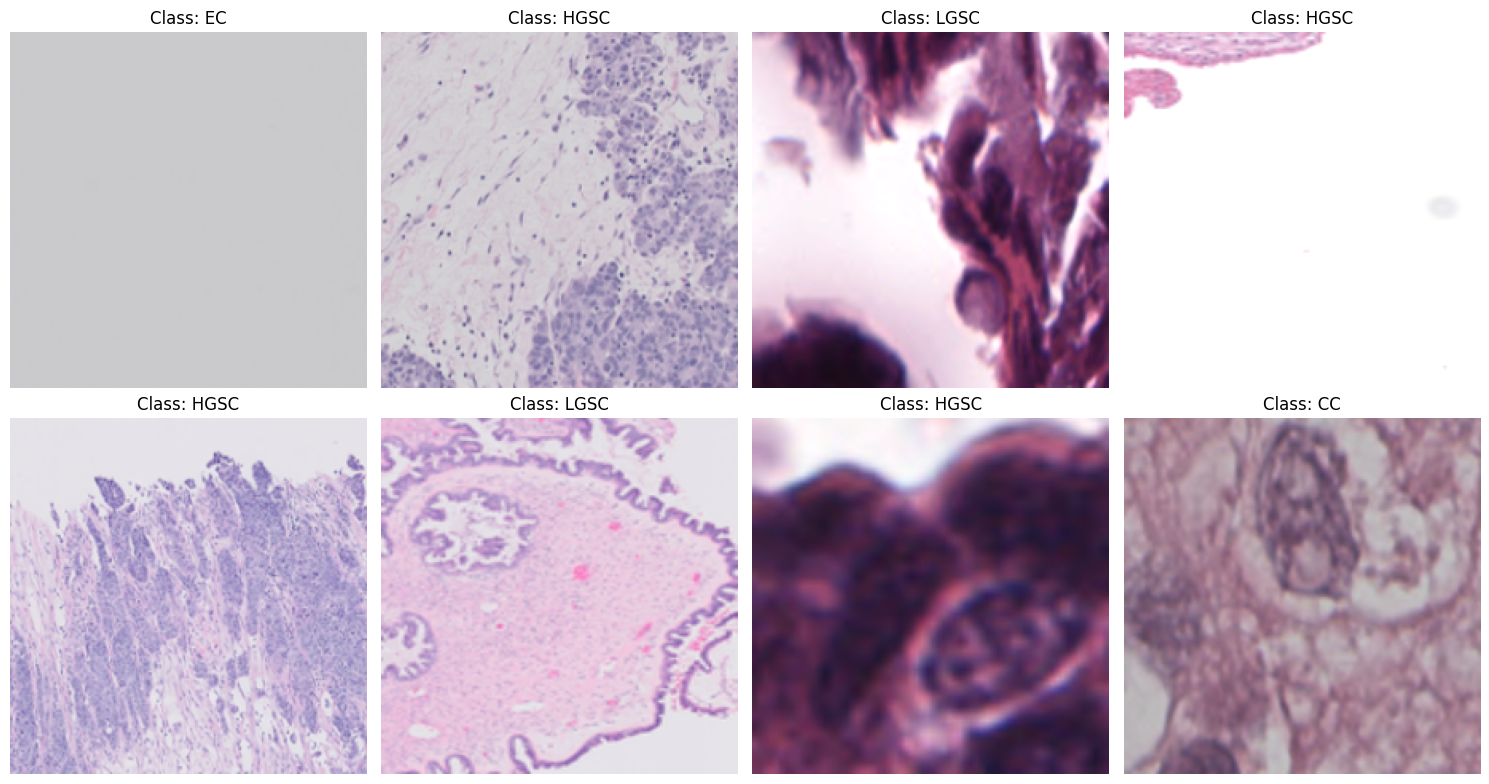

In [13]:
visualizer = Visualizer()
visualizer.show_sample_images(train_dataset)

In [14]:
sample_image, _ = train_dataset[0]
logger.info(f"Image shape: {sample_image.shape}")

[2025-08-02 15:59:50] INFO - Image shape: torch.Size([3, 224, 224])


## Transfer Learning e Fine Tunning com modelo ResNet18

In [16]:
resnet_weights = models.ResNet18_Weights.DEFAULT
resnet_model = models.resnet18(weights=resnet_weights)
print(resnet_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### 🧠 ResNet-18: Resumo da Arquitetura

#### Visão Geral

A **ResNet-18** (Residual Network com 18 camadas treináveis) é uma rede convolucional profunda desenvolvida por He et al. (2015) e é conhecida por introduzir os **blocos residuais**, que utilizam conexões de atalho (*skip connections*) para mitigar o problema de degradação do desempenho em redes muito profundas.

Ela é composta principalmente por **BasicBlocks**, que somam a entrada da camada com a sua saída transformada, facilitando o fluxo de gradientes durante o treinamento.

---

#### Arquitetura Detalhada

A estrutura padrão da **ResNet-18** é a seguinte:

1. **Entrada (conv1)**  
   - `Conv2d`: 3 canais → 64 canais, kernel 7x7, stride 2, padding 3  
   - `BatchNorm2d`, `ReLU`, seguido por `MaxPool2d` (3x3, stride 2)

2. **Blocos Residuais**:
   - `Layer1 (Conv2_x)`:  
     - 2 × `BasicBlock(64 → 64)`, stride 1  
   - `Layer2 (Conv3_x)`:  
     - 2 × `BasicBlock(64 → 128)`, stride 2 no primeiro bloco  
   - `Layer3 (Conv4_x)`:  
     - 2 × `BasicBlock(128 → 256)`, stride 2 no primeiro bloco  
   - `Layer4 (Conv5_x)`:  
     - 2 × `BasicBlock(256 → 512)`, stride 2 no primeiro bloco  

3. **Classificação Final**:
   - `AdaptiveAvgPool2d(output_size=(1, 1))`  
   - `Linear(in_features=512, out_features=1000)` → **Classificação em 1000 classes**

---

#### Características dos BasicBlocks

Cada `BasicBlock` contém:
- Duas camadas `Conv2d` com kernel 3x3 e stride 1
- `BatchNorm2d` após cada convolução
- `ReLU` após a primeira BN
- Uma soma da entrada com a saída do bloco (`residual connection`)
- Quando a dimensão muda, é aplicada uma `downsample` no atalho usando `Conv1x1`

---

#### Dados de Treinamento Original

A ResNet-18 foi originalmente treinada no **ImageNet**, especificamente no desafio **ILSVRC (ImageNet Large Scale Visual Recognition Challenge)**.

- 📦 **Dataset**: ImageNet 1K
- 🔢 **Número de classes**: 1000
- 🖼️ **Número de imagens**: ~1.2 milhões para treino, ~50 mil para validação
- 📂 **Tarefas**: Classificação de imagens em larga escala

---

#### Aplicações e Uso

- **Transfer Learning**: pode ser usada como base para tarefas com menos classes, substituindo a camada `fc` final.
- **Fine-tuning**: é possível descongelar apenas algumas camadas para adaptação a novos domínios.


### Atualizando apenas os pesos da nova camada de classificação

O bloco abaixo de código detalha o processo de construção e configuração de um modelo de aprendizado de máquina para treinamento. Inicialmente, na fase de **construção do modelo**, utiliza-se um modelo ResNet-18 pré-treinado como base, adaptando-o para uma nova tarefa de classificação com cinco classes. Um passo fundamental é o uso do parâmetro `freeze_features=True`, que congela os pesos do modelo ResNet-18, garantindo que eles não sejam alterados durante o treinamento. Isso significa que apenas os pesos da nova camada de classificação adicionada serão atualizados, uma técnica eficaz de aprendizagem por transferência (*transfer learning*).

Em seguida, o código **conta e exibe o número de parâmetros** totais e treináveis do modelo, evidenciando que, devido ao congelamento, a quantidade de parâmetros treináveis é significativamente pequena em comparação ao total. Por fim, são definidos a **função de perda e o otimizador**. A `CrossEntropyLoss` é escolhida como a função de perda, padrão para problemas de classificação multiclasse. O otimizador `Adam` é configurado de forma a receber e atualizar apenas os parâmetros que são treináveis (`requires_grad` é `True`), assegurando que as camadas congeladas permaneçam intactas, enquanto ajusta os pesos da nova camada de classificação com uma taxa de aprendizado (*learning rate*) pré-definida.

In [17]:
logger.info("=== Model Construction Phase ===")
model = ModelBuilder.build_model(
    num_classes=5,
    model=resnet_model,
    weights=resnet_weights,
    freeze_features=True
)

trainable_params, total_params = ModelBuilder.count_parameters(model)
logger.info(f"Model parameters - Trainable: {trainable_params:,}, "
            f"Total: {total_params:,}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=config.learning_rate)

[2025-08-02 16:23:47] INFO - === Model Construction Phase ===
[2025-08-02 16:23:47] INFO - Building the model with pre-trained weights...
[2025-08-02 16:23:47] INFO - Freezing all model parameters...
[2025-08-02 16:23:47] INFO - Model built successfully.
[2025-08-02 16:23:47] INFO - Model parameters - Trainable: 2,565, Total: 11,179,077


In [18]:
logger.info("=== Training Phase ===")
trainer = Trainer(config)
history = trainer.train_model(
    model, train_loader, val_loader, criterion, optimizer
)

[2025-08-02 16:24:31] INFO - === Training Phase ===
[2025-08-02 16:24:31] INFO - Using device: cuda
[2025-08-02 16:24:31] INFO - Starting model training...


Validation: 100%|██████████| 97/97 [00:12<00:00,  7.60it/s]


[2025-08-02 16:27:37] INFO - Epoch 1/15 - Train Loss: 1.360, Train Acc: 42.78% - Val Loss: 1.225, Val Acc: 51.46%
[2025-08-02 16:27:37] INFO - New best validation loss: 1.225


Validation: 100%|██████████| 97/97 [00:11<00:00,  8.23it/s]


[2025-08-02 16:30:39] INFO - Epoch 2/15 - Train Loss: 1.209, Train Acc: 51.40% - Val Loss: 1.142, Val Acc: 54.96%
[2025-08-02 16:30:39] INFO - New best validation loss: 1.142


...

[2025-08-02 17:04:03] INFO - Epoch 13/15 - Train Loss: 1.086, Train Acc: 56.09% - Val Loss: 1.027, Val Acc: 59.77%
[2025-08-02 17:04:03] INFO - No improvement for 3 epoch(s)


Validation: 100%|██████████| 97/97 [00:12<00:00,  8.00it/s]


[2025-08-02 17:07:07] INFO - Epoch 14/15 - Train Loss: 1.081, Train Acc: 56.35% - Val Loss: 1.017, Val Acc: 60.71%
[2025-08-02 17:07:07] INFO - New best validation loss: 1.017


Validation: 100%|██████████| 97/97 [00:11<00:00,  8.39it/s]

[2025-08-02 17:10:10] INFO - Epoch 15/15 - Train Loss: 1.085, Train Acc: 56.24% - Val Loss: 1.018, Val Acc: 60.35%
[2025-08-02 17:10:10] INFO - No improvement for 1 epoch(s)
[2025-08-02 17:10:10] INFO - Loaded best model state
[2025-08-02 17:10:10] INFO - Training completed successfully


### ResNet18 - Histórico de treinamento (Transfer Learning)

[2025-08-02 17:10:10] INFO - === Results Visualization ===


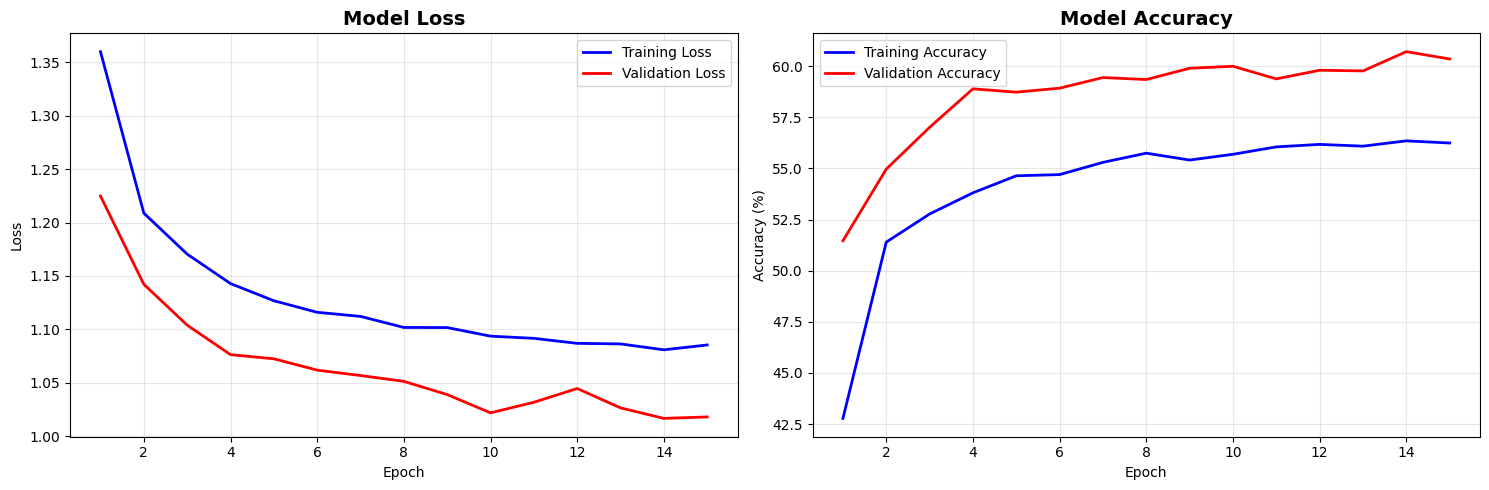

In [19]:
logger.info("=== Results Visualization ===")
visualizer = Visualizer()
visualizer.plot_training_history(history)


### Construção de um modelo ResNet-18 modificado para uma tarefa de fine-tuning

O código abaixo detalha a construção de um modelo ResNet-18 modificado para uma tarefa de *fine-tuning* (ajuste fino). Primeiramente, o modelo é criado usando uma arquitetura ResNet-18 pré-treinada, que é adaptada para uma nova tarefa de classificação com 5 classes. A estratégia principal envolve congelar todos os pesos do modelo, exceto os da camada `layer4`, que são mantidos treináveis. Essa abordagem permite que o modelo aprenda características específicas do novo conjunto de dados em suas camadas mais profundas, enquanto aproveita o conhecimento genérico já aprendido nas camadas iniciais.

Após a construção, o código calcula o número de parâmetros treináveis, que é significativamente maior devido ao descongelamento da `layer4`. A função de perda escolhida é a `CrossEntropyLoss`, padrão para classificação multiclasse. Por fim, é configurado um otimizador Adam com uma técnica eficaz de taxas de aprendizado diferenciadas: a camada `layer4` utiliza uma taxa de aprendizado baixa (ex: 0.0001), pois precisa apenas de pequenos ajustes. Em contraste, a nova camada de classificação totalmente conectada (`fc`), que é inicializada do zero, usa uma taxa de aprendizado mais alta (ex: 0.001) para aprender suas características de forma mais rápida.

In [26]:
logger.info("=== Model Construction Phase ===")
resnet_fine_tuning_model = ModelBuilder.build_model(
    num_classes=5,
    model=resnet_model,
    weights=resnet_weights,
    freeze_features=True,
    unfreeze_layers=['layer4']
)

trainable_params, total_params = ModelBuilder.count_parameters(resnet_fine_tuning_model)
logger.info(f"Model parameters - Trainable: {trainable_params:,}, "
            f"Total: {total_params:,}")

criterion = nn.CrossEntropyLoss()

layer4_params = filter(lambda p: p.requires_grad, resnet_fine_tuning_model.layer4.parameters())
fc_params = filter(lambda p: p.requires_grad, resnet_fine_tuning_model.fc.parameters())

optimizer = optim.Adam([
    {'params': layer4_params, 'lr': 0.0001},
    {'params': fc_params, 'lr': 0.001}
])

[2025-08-02 17:32:43] INFO - === Model Construction Phase ===
[2025-08-02 17:32:43] INFO - Building the model with pre-trained weights...
[2025-08-02 17:32:43] INFO - Freezing all model parameters...
[2025-08-02 17:32:43] INFO - Unfreezing ResNet layer: layer4
[2025-08-02 17:32:43] INFO - Model built successfully.
[2025-08-02 17:32:43] INFO - Model parameters - Trainable: 8,396,293, Total: 11,179,077


In [27]:
logger.info("=== Training Phase ===")
trainer = Trainer(config)
history = trainer.train_model(
    resnet_fine_tuning_model, train_loader, val_loader, criterion, optimizer
)

[2025-08-02 17:33:41] INFO - === Training Phase ===
[2025-08-02 17:33:41] INFO - Using device: cuda
[2025-08-02 17:33:41] INFO - Starting model training...


Validation: 100%|██████████| 97/97 [00:11<00:00,  8.49it/s]


[2025-08-02 17:36:58] INFO - Epoch 1/15 - Train Loss: 0.980, Train Acc: 60.76% - Val Loss: 0.728, Val Acc: 72.13%
[2025-08-02 17:36:58] INFO - New best validation loss: 0.728


Validation: 100%|██████████| 97/97 [00:12<00:00,  8.05it/s]


[2025-08-02 17:40:03] INFO - Epoch 2/15 - Train Loss: 0.811, Train Acc: 68.06% - Val Loss: 0.625, Val Acc: 75.57%
[2025-08-02 17:40:03] INFO - New best validation loss: 0.625


...

[2025-08-02 18:13:38] INFO - Epoch 13/15 - Train Loss: 0.508, Train Acc: 80.33% - Val Loss: 0.460, Val Acc: 83.55%
[2025-08-02 18:13:38] INFO - No improvement for 1 epoch(s)


Validation: 100%|██████████| 97/97 [00:11<00:00,  8.29it/s]


[2025-08-02 18:16:39] INFO - Epoch 14/15 - Train Loss: 0.498, Train Acc: 80.93% - Val Loss: 0.411, Val Acc: 84.72%
[2025-08-02 18:16:39] INFO - New best validation loss: 0.411


Validation: 100%|██████████| 97/97 [00:12<00:00,  8.00it/s]

[2025-08-02 18:19:46] INFO - Epoch 15/15 - Train Loss: 0.486, Train Acc: 81.26% - Val Loss: 0.409, Val Acc: 84.82%
[2025-08-02 18:19:46] INFO - New best validation loss: 0.409
[2025-08-02 18:19:46] INFO - Loaded best model state
[2025-08-02 18:19:46] INFO - Training completed successfully


### ResNet18 - Histórico de treinamento (Fine Tuning)

[2025-08-02 18:19:46] INFO - === Results Visualization ===


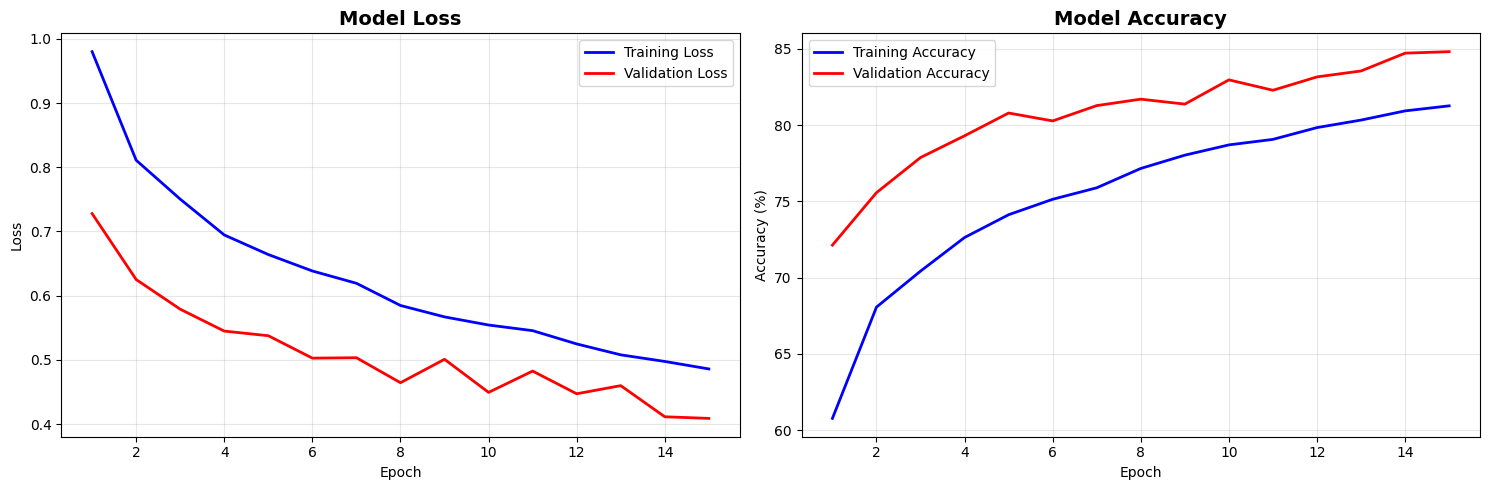

In [28]:
logger.info("=== Results Visualization ===")
visualizer = Visualizer()
visualizer.plot_training_history(history)

### Análise das Curvas de Treinamento - ResNet-18

O modelo ResNet-18 aplicado à classificação de subtipos de câncer ovariano (5 classes) apresenta um desempenho geral satisfatório, com accuracy de validação atingindo 85%. A estratégia de fine-tuning com descongelamento seletivo das camadas `layer4` e `fc` mostrou-se eficaz, porém há sinais de leve overfitting que requerem atenção.

#### Análise das Métricas

##### Loss Function
- **Convergência Estável**: Ambas as curvas mostram tendência decrescente consistente ao longo das 15 épocas
- **Gap Controlado**: A diferença entre training e validation loss mantém-se dentro de limites aceitáveis
- **Possível Overfitting**: Leve divergência observada após a época 6-7, com validation loss estabilizando em ~0.4

##### Accuracy Performance
- **Training Accuracy**: Crescimento progressivo até 81%, demonstrando boa capacidade de aprendizado
- **Validation Accuracy**: Pico de 85%, excelente para um problema de 5 classes em dados médicos
- **Estabilização**: Validation accuracy apresenta platô após época 8, sugerindo convergência

#### Pontos Fortes da Implementação

- **Estratégia de Fine-tuning**: Descongelamento seletivo de camadas específicas foi bem executado
- **Learning Rates Diferenciados**: Abordagem sofisticada para otimização de camadas distintas
- **Performance Final**: 85% de accuracy é um resultado promissor para classificação médica
- **Estabilidade**: Ausência de oscilações bruscas indica treinamento bem controlado

#### Áreas de Melhoria

##### Regularização
- Implementar dropout adicional nas camadas finais
- Considerar weight decay mais agressivo
- Avaliar técnicas de data augmentation específicas para imagens médicas

### Otimização
- Ajustar learning rates para reduzir overfitting inicial
- Implementar learning rate scheduling (ReduceLROnPlateau)
- Considerar early stopping com patience de 3-5 épocas

### Validação
- Aplicar validação cruzada para datasets médicos limitados
- Avaliar métricas específicas do domínio (sensibilidade, especificidade)
- Testar em conjunto independente para confirmar generalização

#### Recomendações Finais

O modelo demonstra aprendizado efetivo com resultados clinicamente relevantes. O leve overfitting observado é comum em fine-tuning e pode ser mitigado com as técnicas de regularização sugeridas. A performance de 85% representa um ponto de partida sólido para aplicação clínica, desde que validado adequadamente em dados independentes.

**Status do Treinamento**: ✅ Bem-sucedido com otimizações recomendadas  
**Próximo Passo**: Implementar regularização adicional e validação em dados de teste

## Transfer Learning e Fine Tunning com modelo Densenet121

In [30]:
densenet121_weights = models.DenseNet121_Weights.DEFAULT
densenet121_model = models.densenet121(weights=densenet121_weights)
print(densenet121_model)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 163MB/s]


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

### 🧠 DenseNet-121 — Visão Geral e Aplicações

**DenseNet-121** é uma arquitetura de rede neural convolucional profunda desenvolvida para promover uma melhor **propagação de gradientes**, **reutilização de características** e **eficiência de parâmetros**. Introduzida por Gao Huang et al. em 2017, no paper *“Densely Connected Convolutional Networks”*, ela pertence à família das DenseNets (DenseNet-121, 169, 201, etc.).

#### 📐 Estrutura e Arquitetura

DenseNet-121 é composta por:

* **121 camadas profundas**
* **4 blocos densos** intercalados por **camadas de transição**
* Cada camada dentro de um bloco denso recebe **como entrada todos os outputs anteriores** (conexões densas)
* Possui aproximadamente **8 milhões de parâmetros**, o que a torna consideravelmente leve frente a outras redes profundas

No final da arquitetura, uma camada **classifier fully connected** recebe **1024 features** e produz a classificação desejada.

#### 🏷️ Classificação e Dataset Original

O modelo DenseNet-121 foi originalmente treinado no dataset **ImageNet**, um conjunto com:

* Mais de **1.2 milhões de imagens**
* Classificação em **1000 categorias** (ex: animais, objetos, instrumentos, etc.)

A última camada (`classifier`) da versão pré-treinada é:

```python
nn.Linear(in_features=1024, out_features=1000)
```

Para tarefas personalizadas (ex: classificação médica), essa camada geralmente é substituída:

```python
model.classifier = nn.Linear(1024, num_classes)
```

#### 🔬 Aplicações em Saúde e Imagens Médicas

DenseNet-121 é amplamente adotada em tarefas médicas por características que favorecem a interpretação de **padrões sutis**:

* **Radiologia** (detecção de pneumonia em raio-X)
* **Histopatologia** (classificação de subtipos de câncer)
* **Dermatologia** (detecção de lesões cutâneas)
* **Oftalmologia** (retinopatia diabética)

📌 Exemplo notável:
No estudo *“CheXNet: Radiologist-Level Pneumonia Detection on Chest X-Rays with Deep Learning”*, DenseNet-121 foi utilizada para superar o desempenho médio de radiologistas humanos na detecção de pneumonia.

#### ⚖️ Comparativo: DenseNet-121 vs ResNet-18

| Característica               | DenseNet-121                                  | ResNet-18                     |
| ---------------------------- | --------------------------------------------- | ----------------------------- |
| Tipo de Conexão              | Conexões densas (todas as camadas anteriores) | Residuais (skip connections)  |
| Profundidade                 | 121 camadas                                   | 18 camadas                    |
| Parâmetros                   | \~8M                                          | \~11M                         |
| Reutilização de Features     | Alta                                          | Moderada                      |
| Propagação de Gradientes     | Muito eficiente                               | Boa                           |
| Desempenho em dados médicos  | Excelente (usada em estudos clínicos)         | Razoável                      |
| Tamanho e Eficiência         | Compacta e precisa                            | Leve, mas menos expressiva    |
| Treinamento com poucos dados | Melhor                                        | Necessita regularização extra |

#### ✅ Por que usar DenseNet-121 em dados médicos?

1. **Melhor fluxo de gradientes** → mais fácil de treinar, mesmo com datasets pequenos
2. **Reutilização de representações intermediárias** → favorece a captação de detalhes morfológicos
3. **Menor risco de overfitting** → importante em contextos médicos com poucos exemplos rotulados
4. **Compatibilidade com métodos de explicabilidade** como **Grad-CAM**, úteis para interpretação clínica
5. **Menor número de parâmetros** → menor uso de memória e tempo de treinamento


### Densenet121 - Histórico de treinamento (Transfer Learning)

In [32]:
logger.info("=== Model Construction Phase ===")
desnsenet_121_transfer_learning_model = ModelBuilder.build_model(
    num_classes=5,
    model=densenet121_model,
    weights=densenet121_weights,
    freeze_features=True
)

trainable_params, total_params = ModelBuilder.count_parameters(desnsenet_121_transfer_learning_model)
logger.info(f"Model parameters - Trainable: {trainable_params:,}, "
            f"Total: {total_params:,}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, desnsenet_121_transfer_learning_model.parameters()), lr=config.learning_rate)

[2025-08-02 18:26:22] INFO - === Model Construction Phase ===
[2025-08-02 18:26:22] INFO - Building the model with pre-trained weights...
[2025-08-02 18:26:22] INFO - Freezing all model parameters...
[2025-08-02 18:26:22] INFO - Model built successfully.
[2025-08-02 18:26:22] INFO - Model parameters - Trainable: 5,125, Total: 6,958,981


In [33]:
logger.info("=== Training Phase ===")
trainer = Trainer(config)
history = trainer.train_model(
    desnsenet_121_transfer_learning_model, train_loader, val_loader, criterion, optimizer
)

[2025-08-02 18:26:28] INFO - === Training Phase ===
[2025-08-02 18:26:28] INFO - Using device: cuda
[2025-08-02 18:26:28] INFO - Starting model training...


Validation: 100%|██████████| 97/97 [00:14<00:00,  6.79it/s]


[2025-08-02 18:29:53] INFO - Epoch 1/15 - Train Loss: 1.342, Train Acc: 44.23% - Val Loss: 1.208, Val Acc: 51.78%
[2025-08-02 18:29:53] INFO - New best validation loss: 1.208


Validation: 100%|██████████| 97/97 [00:14<00:00,  6.62it/s]


[2025-08-02 18:33:21] INFO - Epoch 2/15 - Train Loss: 1.199, Train Acc: 52.33% - Val Loss: 1.139, Val Acc: 55.65%
[2025-08-02 18:33:21] INFO - New best validation loss: 1.139


...

[2025-08-02 19:11:31] INFO - Epoch 13/15 - Train Loss: 1.044, Train Acc: 58.66% - Val Loss: 0.982, Val Acc: 62.88%
[2025-08-02 19:11:31] INFO - New best validation loss: 0.982


Validation: 100%|██████████| 97/97 [00:13<00:00,  7.03it/s]


[2025-08-02 19:14:59] INFO - Epoch 14/15 - Train Loss: 1.041, Train Acc: 58.65% - Val Loss: 0.979, Val Acc: 63.08%
[2025-08-02 19:14:59] INFO - New best validation loss: 0.979


Validation: 100%|██████████| 97/97 [00:13<00:00,  7.02it/s]

[2025-08-02 19:18:21] INFO - Epoch 15/15 - Train Loss: 1.043, Train Acc: 58.64% - Val Loss: 1.031, Val Acc: 60.29%
[2025-08-02 19:18:21] INFO - No improvement for 1 epoch(s)
[2025-08-02 19:18:21] INFO - Loaded best model state
[2025-08-02 19:18:21] INFO - Training completed successfully


[2025-08-02 19:18:21] INFO - === Results Visualization ===


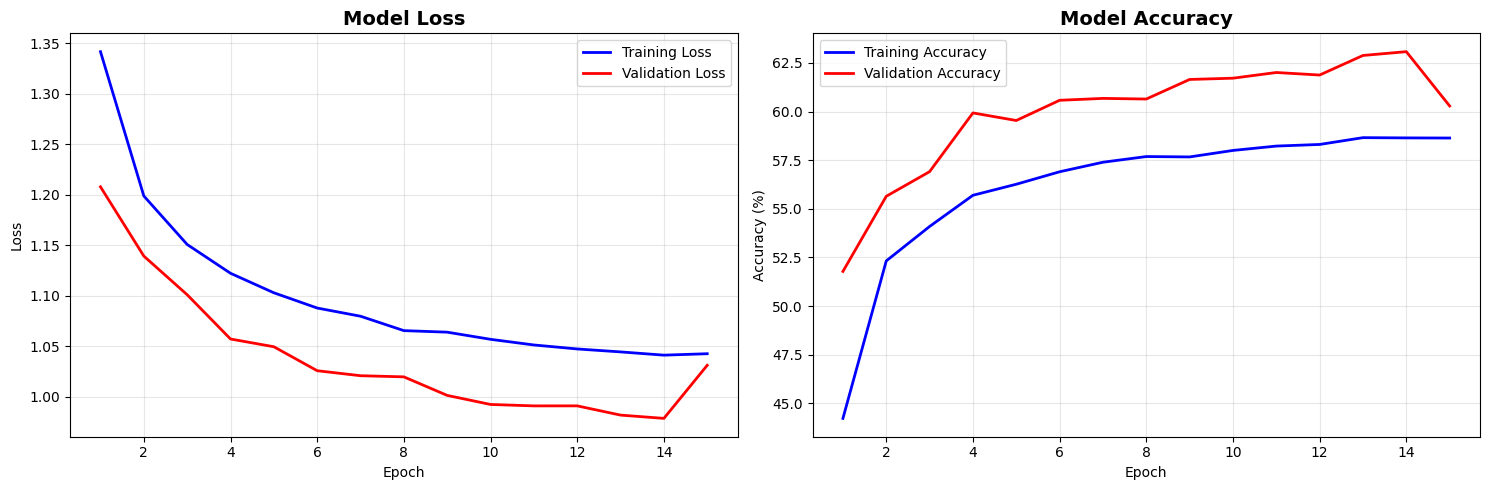

In [34]:
logger.info("=== Results Visualization ===")
visualizer = Visualizer()
visualizer.plot_training_history(history)

### Densenet121 modificado para uma tarefa de fine-tuning

In [35]:
logger.info("=== Model Construction Phase ===")
densenet_121_fine_tuning_model = ModelBuilder.build_model(
    num_classes=5,
    model=densenet121_model,
    weights=densenet121_weights,
    freeze_features=True,
    unfreeze_layers=["denseblock4", "norm5"]
)

trainable_params, total_params = ModelBuilder.count_parameters(densenet_121_fine_tuning_model)
logger.info(f"Model parameters - Trainable: {trainable_params:,}, "
            f"Total: {total_params:,}")

criterion = nn.CrossEntropyLoss()

classifier_params = filter(lambda p: p.requires_grad, densenet_121_fine_tuning_model.classifier.parameters())
denseblock4_params = filter(lambda p: p.requires_grad, densenet_121_fine_tuning_model.features.denseblock4.parameters())
norm5_params = filter(lambda p: p.requires_grad, densenet_121_fine_tuning_model.features.norm5.parameters())

optimizer = optim.Adam([
    {'params': denseblock4_params, 'lr': 0.0001},
    {'params': norm5_params, 'lr': 0.0001},
    {'params': classifier_params, 'lr': 0.001},
])

[2025-08-02 19:20:36] INFO - === Model Construction Phase ===
[2025-08-02 19:20:36] INFO - Building the model with pre-trained weights...
[2025-08-02 19:20:36] INFO - Freezing all model parameters...
[2025-08-02 19:20:36] INFO - Unfreezing DenseNet layer: denseblock4
[2025-08-02 19:20:36] INFO - Unfreezing DenseNet layer: norm5
[2025-08-02 19:20:36] INFO - Model built successfully.
[2025-08-02 19:20:36] INFO - Model parameters - Trainable: 2,165,253, Total: 6,958,981


In [36]:
logger.info("=== Training Phase ===")
trainer = Trainer(config)
history = trainer.train_model(
    densenet_121_fine_tuning_model, train_loader, val_loader, criterion, optimizer
)

[2025-08-02 19:20:48] INFO - === Training Phase ===
[2025-08-02 19:20:48] INFO - Using device: cuda
[2025-08-02 19:20:48] INFO - Starting model training...


Validation: 100%|██████████| 97/97 [00:13<00:00,  6.97it/s]


[2025-08-02 19:24:15] INFO - Epoch 1/15 - Train Loss: 0.985, Train Acc: 60.46% - Val Loss: 0.721, Val Acc: 72.23%
[2025-08-02 19:24:15] INFO - New best validation loss: 0.721


Validation: 100%|██████████| 97/97 [00:13<00:00,  6.93it/s]


[2025-08-02 19:27:46] INFO - Epoch 2/15 - Train Loss: 0.801, Train Acc: 68.48% - Val Loss: 0.627, Val Acc: 76.51%
[2025-08-02 19:27:46] INFO - New best validation loss: 0.627


...

[2025-08-02 20:06:02] INFO - Epoch 13/15 - Train Loss: 0.516, Train Acc: 80.01% - Val Loss: 0.457, Val Acc: 83.39%
[2025-08-02 20:06:02] INFO - New best validation loss: 0.457


Validation: 100%|██████████| 97/97 [00:13<00:00,  6.97it/s]


[2025-08-02 20:09:32] INFO - Epoch 14/15 - Train Loss: 0.515, Train Acc: 80.05% - Val Loss: 0.465, Val Acc: 82.84%
[2025-08-02 20:09:32] INFO - No improvement for 1 epoch(s)


Validation: 100%|██████████| 97/97 [00:13<00:00,  7.02it/s]

[2025-08-02 20:13:01] INFO - Epoch 15/15 - Train Loss: 0.505, Train Acc: 80.50% - Val Loss: 0.489, Val Acc: 81.47%
[2025-08-02 20:13:01] INFO - No improvement for 2 epoch(s)
[2025-08-02 20:13:01] INFO - Loaded best model state
[2025-08-02 20:13:01] INFO - Training completed successfully


[2025-08-02 20:13:01] INFO - === Results Visualization ===


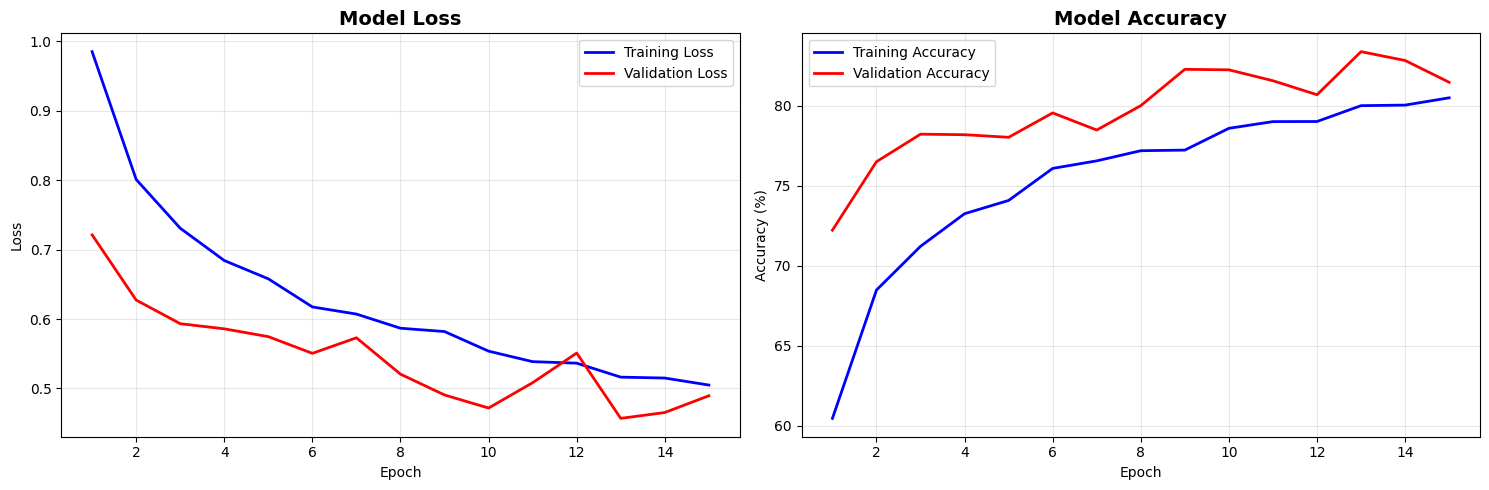

In [37]:
logger.info("=== Results Visualization ===")
visualizer = Visualizer()
visualizer.plot_training_history(history)

### Análise das Curvas de Treinamento - DenseNet-121

O modelo DenseNet-121 para classificação de subtipos de câncer ovariano (5 classes) apresenta instabilidade significativa durante o treinamento, apesar de alcançar accuracy de validação de ~85%. A estratégia de fine-tuning com descongelamento das camadas `denseblock4`, `norm5` e `classifier` requer ajustes críticos para estabilizar o processo de aprendizado.

#### Análise das Métricas

##### Loss Function
- **Convergência Inicial**: Progresso satisfatório nas primeiras 6 épocas
- **Instabilidade Crítica**: Pico abrupto no validation loss na época 12 (~0.55)
- **Recovery Parcial**: Recuperação nas épocas finais, mas sem estabilização completa
- **Training vs Validation**: Gap moderado com training loss atingindo ~0.51

##### Accuracy Performance
- **Training Accuracy**: Crescimento progressivo até 81%
- **Validation Accuracy**: Picos de 85% com oscilações significativas
- **Volatilidade**: Flutuações constantes entre 80-85% nas últimas épocas
- **Instabilidade**: Queda abrupta na época 12 seguida de recuperação

#### Problemas Identificados

##### Instabilidade de Treinamento
- **Pico na época 12**: Indica possível learning rate inadequado ou batch instável
- **Oscilações excessivas**: Validation metrics mostram alta volatilidade
- **Falta de convergência**: Ausência de plateau estável nas métricas

##### Características da DenseNet
- **Sensibilidade aumentada**: Conexões densas tornam a rede mais sensível a hiperparâmetros
- **Propagação complexa**: Gradientes mais complexos requerem cuidado especial
- **Regularização insuficiente**: Arquitetura densa demanda mais controle de overfitting

#### Comparação com ResNet-18

| Aspecto | ResNet-18 | DenseNet-121 |
|---------|-----------|---------------|
| **Estabilidade** | Excelente | Instável |
| **Accuracy Final** | 85% | 85% |
| **Convergência** | Suave e consistente | Irregular com picos |